# GlucoSense — Risk-Aware Insulin Recommendation System

**Multi-class classification** pipeline predicting insulin adjustment classes (steady, up, down, no) with:
- Explainability (SHAP, feature importance, partial dependence)
- Uncertainty estimation & risk-aware safeguards
- Data-driven dose adjustment from patient features

**Pipeline:** 1.Load → 2.EDA → 3.Clean → 4.Encode → 5.EDA Visuals → 6.Feature Selection → 7.Scale & Split → 8.Train ML/RNN → 9.Evaluate → 10.Hyperparameter → 11.Explainability → 12.Recommendation → 13.Save → 14.Abstracted Mode

## 1. Data Loading and Understanding

In [18]:
import sys
from pathlib import Path

# Resolve project root (works from notebooks/ or project root)
_root = Path(".").resolve()
if not (_root / "data" / "SmartSensor_DiabetesMonitoring.csv").exists():
    _root = Path("..").resolve()
sys.path.insert(0, str(_root / "src"))

# Output directory for EDA visualizations and pipeline artifacts (aligned with system outputs/)
OUTPUT_DIR = _root / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / "eda").mkdir(exist_ok=True)

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from insulin_system.data_processing.load import load_and_validate
from insulin_system.config.schema import DataSchema

DATA_PATH = _root / "data" / "SmartSensor_DiabetesMonitoring.csv"
schema = DataSchema()

In [39]:
# Load dataset
df = load_and_validate(DATA_PATH)
df.head()

,patient_id,gender,age,family_history,glucose_level,physical_activity,food_intake,previous_medications,BMI,HbA1c,weight,insulin_sensitivity,sleep_hours,creatinine,Insulin
0,1,male,68,yes,103.49,9.28,high,none,33.87,7.42,54.77,1.49,6.07,0.63,steady
1,2,female,57,yes,113.35,6.67,high,insulin,19.10,11.66,114.93,1.35,8.60,1.08,up
2,3,male,24,yes,127.40,4.14,medium,oral,22.48,5.72,59.07,0.96,5.19,1.36,up
3,4,male,49,yes,138.79,6.80,medium,oral,31.67,11.91,50.81,0.61,4.79,1.23,up
4,5,male,65,no,128.42,4.01,low,insulin,28.50,5.72,65.95,1.16,7.68,0.62,steady


In [40]:
#drop the patient id column as it is not useful for prediction
df.drop(columns=["patient_id"], inplace=True)

In [41]:
df.head()

,gender,age,family_history,glucose_level,physical_activity,food_intake,previous_medications,BMI,HbA1c,weight,insulin_sensitivity,sleep_hours,creatinine,Insulin
0,male,68,yes,103.49,9.28,high,none,33.87,7.42,54.77,1.49,6.07,0.63,steady
1,female,57,yes,113.35,6.67,high,insulin,19.10,11.66,114.93,1.35,8.60,1.08,up
2,male,24,yes,127.40,4.14,medium,oral,22.48,5.72,59.07,0.96,5.19,1.36,up
3,male,49,yes,138.79,6.80,medium,oral,31.67,11.91,50.81,0.61,4.79,1.23,up
4,male,65,no,128.42,4.01,low,insulin,28.50,5.72,65.95,1.16,7.68,0.62,steady


## 2. Exploratory Data Analysis (Basic)

Data quality: duplicates, summary statistics, missing values.

In [42]:
def eda_section(df, title, func):
    print(f"\n{'='*20} {title} {'='*20}")
    func(df)
    print('-'*65)


def report_missing(df):
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print("No missing values.")
    else:
        print(missing.sort_values(ascending=False))
        print(f"\nTotal missing cells: {missing.sum():,} "
              f"({missing.sum() / df.size:.2%} of all data)")


def run_eda(df, target_column=None):
    print("\n" + "="*70)
    print(" BASIC EXPLORATORY DATA ANALYSIS".center(70))
    print("="*70)
    
    # 1. Basic information
    eda_section(df, "DataSet Info", 
                lambda d: d.info(verbose=True, memory_usage=True, show_counts=True))
    
    # 2. Shape & duplicates
    eda_section(df, "Shape & Duplicates", 
                lambda d: print(f"Rows: {d.shape[0]:,}    Columns: {d.shape[1]:,}\n"
                               f"Duplicate rows: {d.duplicated().sum():,} "
                               f"({d.duplicated().sum()/len(d):.2%})"))
    
    # 3. Missing values
    eda_section(df, "Missing Values", report_missing)
    
    # 4. Data types summary
    eda_section(df, "Data Types", 
                lambda d: print(d.dtypes.value_counts().to_frame("count")))
    
    # 5. Summary statistics (numerical + categorical)
    eda_section(df, "Summary Statistics (describe)", 
                lambda d: display(d.describe()))
    
    # 6. Target variable distribution (if provided)
    if target_column and target_column in df.columns:
        eda_section(df, f"Target Variable: {target_column}", 
                    lambda d: print(d[target_column].value_counts(dropna=False).to_frame("count"))
                             or print("\nPercentages:") 
                             or print(d[target_column].value_counts(normalize=True)
                                      .mul(100).round(1).astype(str) + " %"))
    else:
        print("\nNo target column specified or column not found.")


In [43]:
# Run EDA
run_eda(df, target_column="Insulin")


                    BASIC EXPLORATORY DATA ANALYSIS                   

==================== DataSet Info ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                10000 non-null  object 
 1   age                   10000 non-null  int64  
 2   family_history        10000 non-null  object 
 3   glucose_level         10000 non-null  float64
 4   physical_activity     10000 non-null  float64
 5   food_intake           10000 non-null  object 
 6   previous_medications  10000 non-null  object 
 7   BMI                   10000 non-null  float64
 8   HbA1c                 10000 non-null  float64
 9   weight                10000 non-null  float64
 10  insulin_sensitivity   10000 non-null  float64
 11  sleep_hours           10000 non-null  float64
 12  creatinine            10000 non-null  float64

,age,glucose_level,physical_activity,BMI,HbA1c,weight,insulin_sensitivity,sleep_hours,creatinine
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,48.332600,136.130545,4.957276,29.100394,8.038930,79.684362,1.002086,6.990714,1.002028
std,17.908044,37.477472,2.862755,6.329743,2.324137,23.198076,0.287446,1.724606,0.288162
min,18.000000,70.010000,0.000000,18.000000,4.000000,40.010000,0.500000,4.000000,0.500000
25%,33.000000,104.047500,2.470000,23.650000,6.040000,59.702500,0.750000,5.480000,0.750000
50%,48.000000,136.835000,4.960000,29.115000,8.010000,79.335000,1.000000,7.010000,1.010000
75%,64.000000,168.020000,7.380000,34.620000,10.100000,99.740000,1.250000,8.470000,1.250000
max,79.000000,199.990000,10.000000,40.000000,12.000000,119.990000,1.500000,10.000000,1.500000


-----------------------------------------------------------------

==================== Target Variable: Insulin ====================
         count
Insulin       
steady    5326
up        3363
no         701
down       610

Percentages:
Insulin
steady    53.3 %
up        33.6 %
no         7.0 %
down       6.1 %
Name: proportion, dtype: object
-----------------------------------------------------------------


## 3. Data Cleaning & 4. Label Encoding

In [45]:
# Outlier detection (IQR + clinical bounds) and clipping
from insulin_system.config.schema import ClinicalBounds
bounds = ClinicalBounds()

def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < (Q1 - 1.5 * IQR)) | (series > (Q3 + 1.5 * IQR))

print("\n=== Outlier Detection (IQR + clinical bounds) ===")
outlier_counts = {}
for col in schema.NUMERIC:
    if col in df:
        try:
            b = bounds.get_bounds_for_column(col)
            outside_bounds = (df[col] < b[0]) | (df[col] > b[1])
            iqr_out = detect_outliers_iqr(df[col])
            n_out = (outside_bounds | iqr_out).sum()
            if n_out > 0:
                outlier_counts[col] = n_out
                df.loc[outside_bounds, col] = df[col].clip(lower=b[0], upper=b[1])
        except KeyError:
            pass

if outlier_counts:
    for col, cnt in outlier_counts.items():
        print(f"  {col}: {cnt} values clipped")
else:
    print("  No outliers beyond clinical bounds.")


=== Outlier Detection (IQR + clinical bounds) ===
  No outliers beyond clinical bounds.


In [46]:
def plot_eda_insulin_visuals(
    df: pd.DataFrame,
    target_col: str = "Insulin",
    numeric_cols: list[str] | None = None,
    output_dir: str | Path = "outputs/eda",
    figsize_num_dist=(12, 10),
    figsize_boxplots=(14, 10),
    figsize_heatmap=(12, 10),
    figsize_class_balance=(8, 5),
    dpi: int = 150,
    save: bool = True,
    show: bool = True
) -> None:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # ────────────────────────────────────────────────
    # Auto-detect numeric columns if not provided
    # ────────────────────────────────────────────────
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        # Optional: exclude target from numeric plots if it's numeric
        if target_col in numeric_cols:
            numeric_cols.remove(target_col)

    numeric_cols = [col for col in numeric_cols if col in df.columns]

    if not numeric_cols:
        print("Warning: No numeric columns found to plot.")

    # ────────────────────────────────────────────────
    # 1. Numerical features distributions (histograms)
    # ────────────────────────────────────────────────
    if numeric_cols:
        n_plots = len(numeric_cols)
        n_rows = (n_plots + 2) // 3   # up to 3 per row
        fig, axes = plt.subplots(n_rows, 3, figsize=figsize_num_dist)
        axes = axes.flatten() if n_rows > 1 else [axes]

        for i, col in enumerate(numeric_cols):
            if i < len(axes):
                df[col].hist(ax=axes[i], bins=30, color="steelblue", edgecolor="white")
                axes[i].set_title(col, fontsize=11)
                axes[i].grid(alpha=0.3)

        # Hide unused subplots
        for j in range(n_plots, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle("Numerical Feature Distributions", fontsize=14, y=1.02)
        plt.tight_layout()

        if save:
            plt.savefig(output_dir / "01_numerical_distributions.png", dpi=dpi, bbox_inches="tight")
        if show:
            plt.show()
        else:
            plt.close(fig)

    # ────────────────────────────────────────────────
    # 2. Boxplots: numeric features vs target
    # ────────────────────────────────────────────────
    if target_col in df.columns and numeric_cols:
        fig, axes = plt.subplots(n_rows, 3, figsize=figsize_boxplots)
        axes = axes.flatten() if n_rows > 1 else [axes]

        for i, col in enumerate(numeric_cols):
            if i < len(axes):
                df.boxplot(column=col, by=target_col, ax=axes[i], patch_artist=True,
                           boxprops=dict(facecolor="#a8dadc"), medianprops=dict(color="darkred"))
                axes[i].set_title(f"{col} by {target_col}", fontsize=11)
                axes[i].set_xlabel("")
                axes[i].grid(alpha=0.3)

        for j in range(len(numeric_cols), len(axes)):
            axes[j].set_visible(False)

        plt.suptitle(f"Numerical Features vs {target_col}", fontsize=14, y=1.02)
        plt.tight_layout()

        if save:
            plt.savefig(output_dir / "02_features_vs_target_boxplots.png", dpi=dpi, bbox_inches="tight")
        if show:
            plt.show()
        else:
            plt.close(fig)

    # ────────────────────────────────────────────────
    # 3. Correlation heatmap
    # ────────────────────────────────────────────────
    if len(df.columns) >= 2:
        corr = df.corr(numeric_only=True)

        plt.figure(figsize=figsize_heatmap)
        sns.heatmap(
            corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.4,
            cbar_kws={"shrink": 0.8}
        )
        plt.title(f"Correlation Matrix (including {target_col})", fontsize=14)
        plt.tight_layout()

        if save:
            plt.savefig(output_dir / "03_correlation_heatmap.png", dpi=dpi, bbox_inches="tight")
        if show:
            plt.show()
        else:
            plt.close()

        # Print strongest correlations with target
        if target_col in corr.columns:
            print(f"\nStrongest correlations with {target_col} (sorted by absolute value):")
            target_corr = corr[target_col].drop(target_col, errors="ignore").sort_values(key=abs, ascending=False)
            print(target_corr.round(3))
            print()

    # ────────────────────────────────────────────────
    # 4. Class balance (bar + percentages)
    # ────────────────────────────────────────────────
    if target_col in df.columns:
        value_counts = df[target_col].value_counts().sort_index()
        percentages = df[target_col].value_counts(normalize=True).sort_index() * 100

        plt.figure(figsize=figsize_class_balance)
        bars = value_counts.plot(
            kind="bar",
            color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6", "#f1c40f"],
            edgecolor="black"
        )
        plt.title(f"Class Distribution – {target_col}", fontsize=13)
        plt.xlabel(target_col)
        plt.ylabel("Count")
        plt.xticks(rotation=0)

        # Add count labels on bars
        for bar in bars.patches:
            bars.annotate(
                f"{int(bar.get_height())}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10
            )

        plt.tight_layout()

        if save:
            plt.savefig(output_dir / "04_class_balance.png", dpi=dpi, bbox_inches="tight")
        if show:
            plt.show()
        else:
            plt.close()

        print(f"\nClass balance – {target_col}:")
        for cls, cnt, pct in zip(value_counts.index, value_counts, percentages):
            print(f"  {cls:>8} : {cnt:>6}  ({pct:5.1f}%)")
        print()


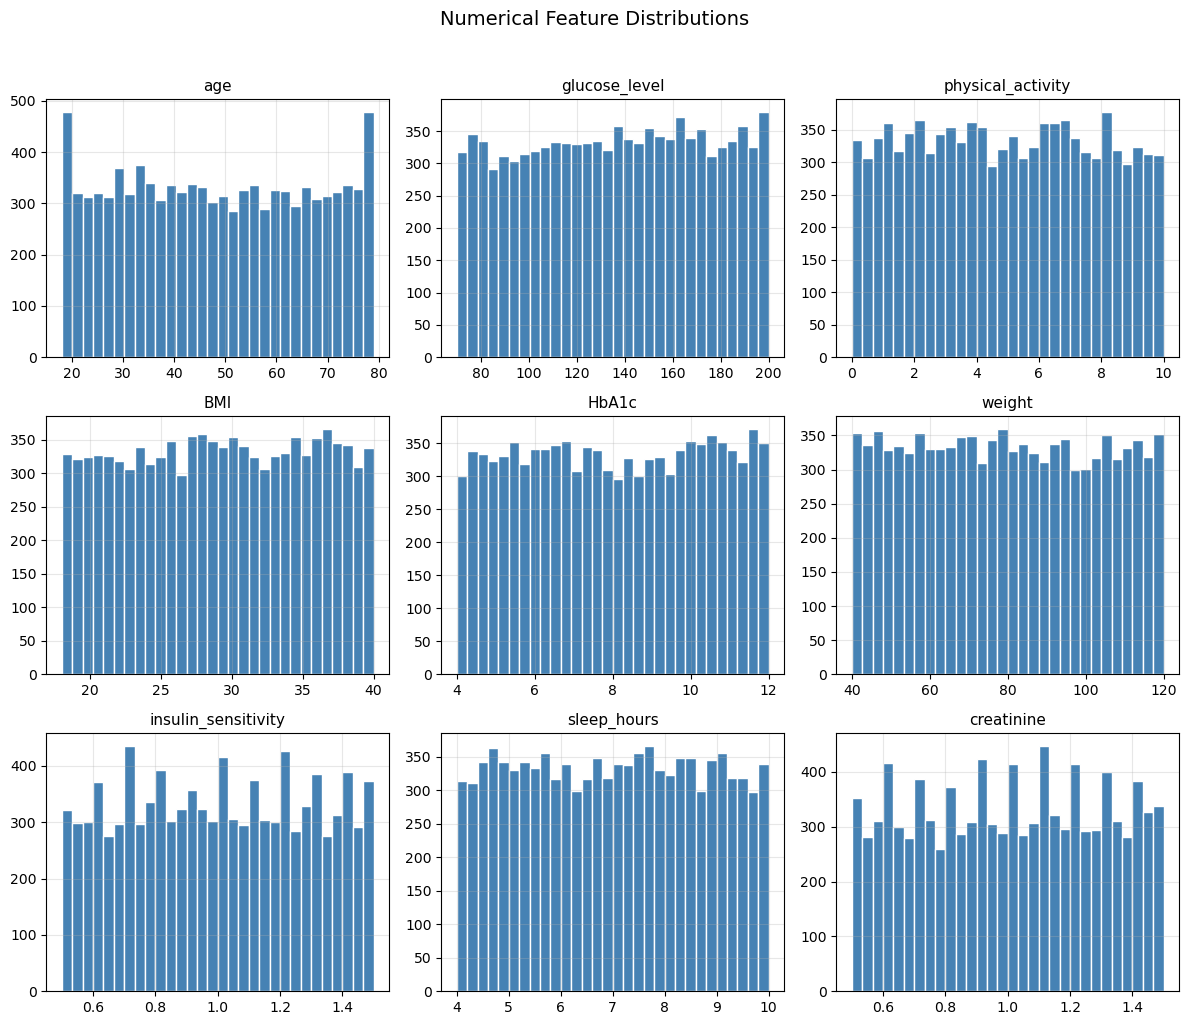

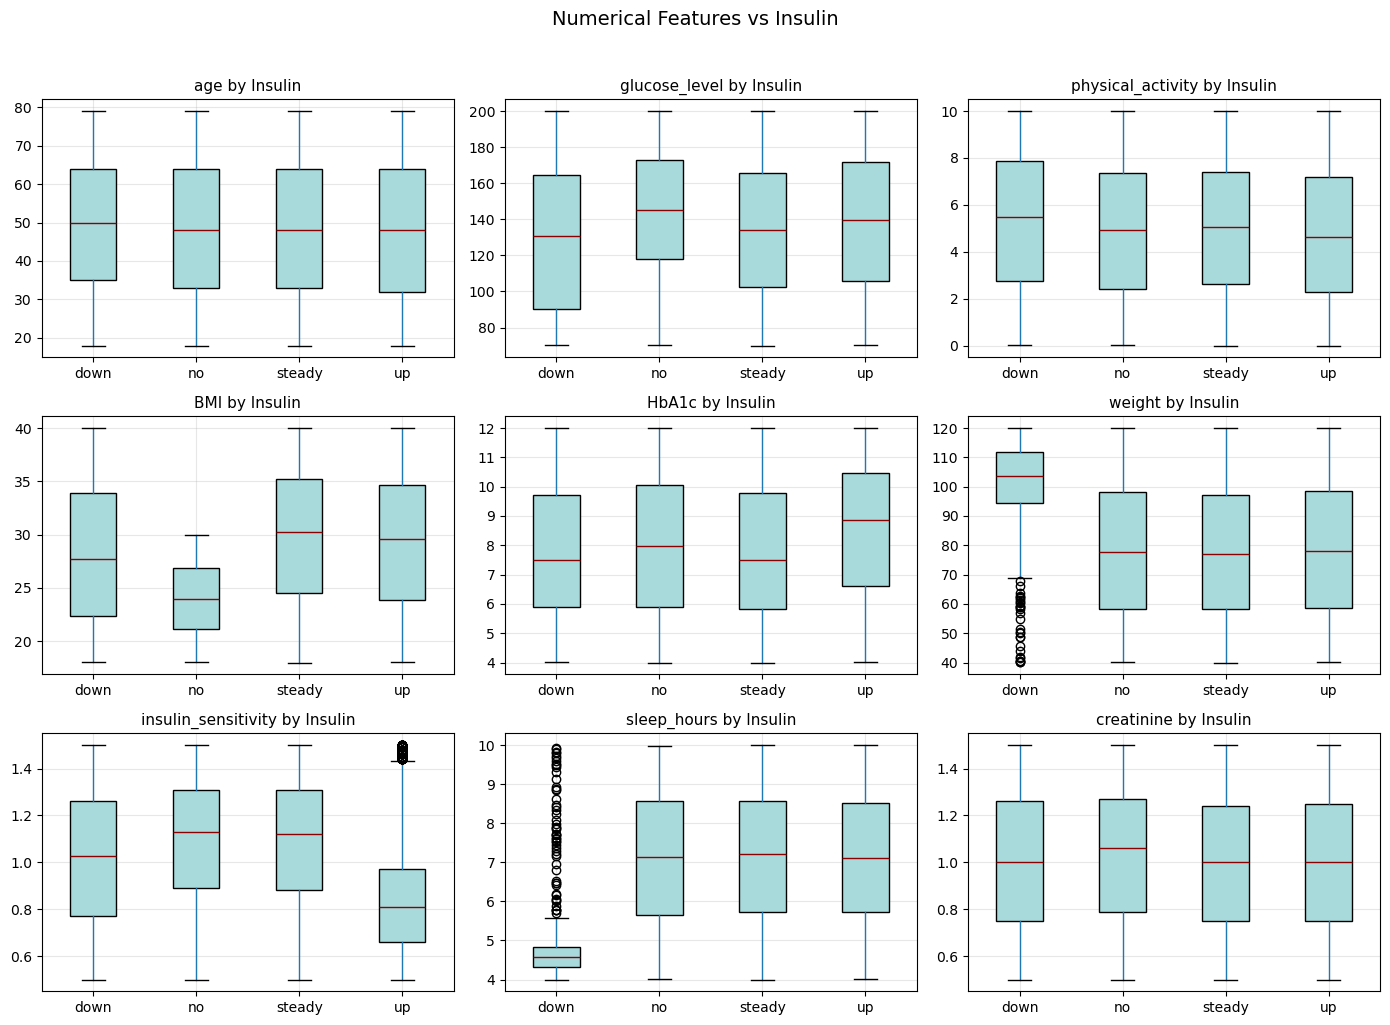

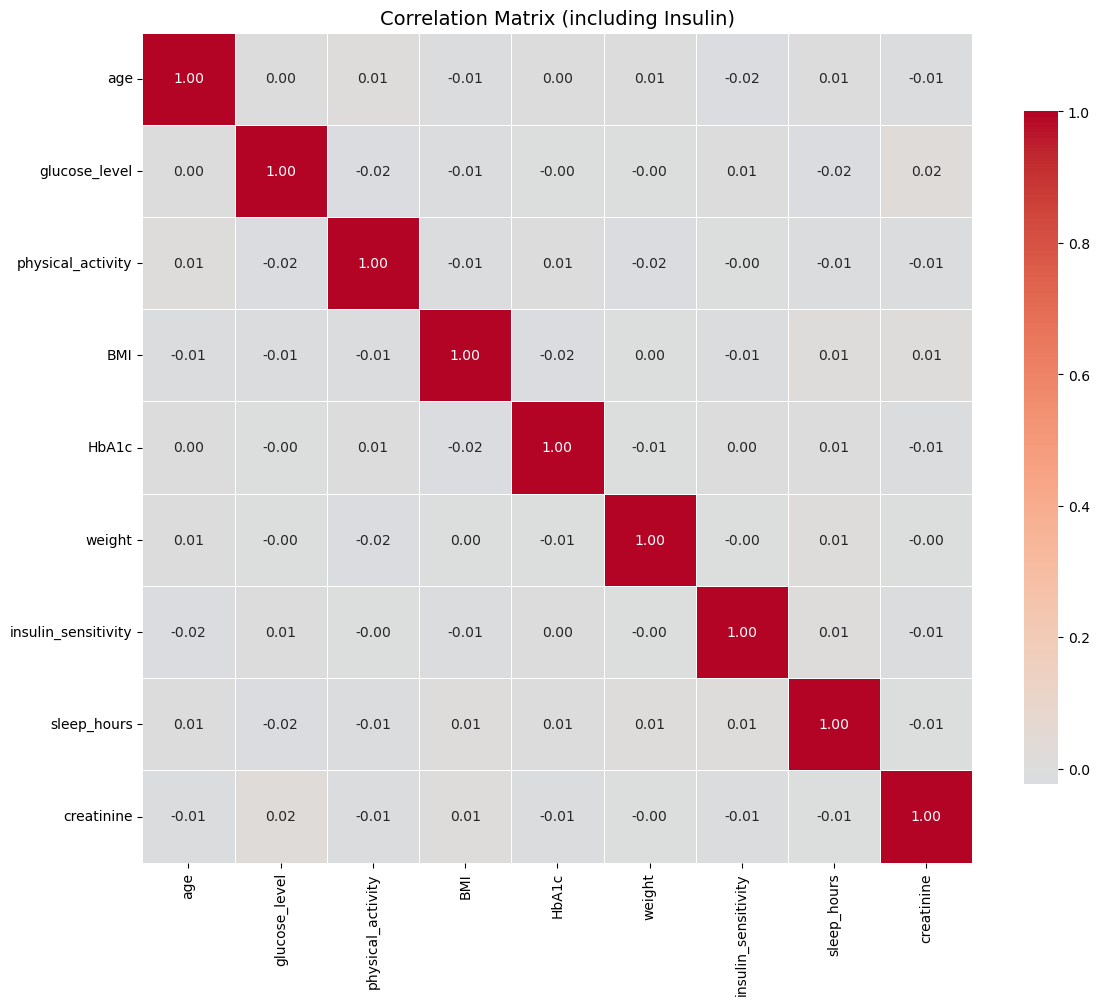

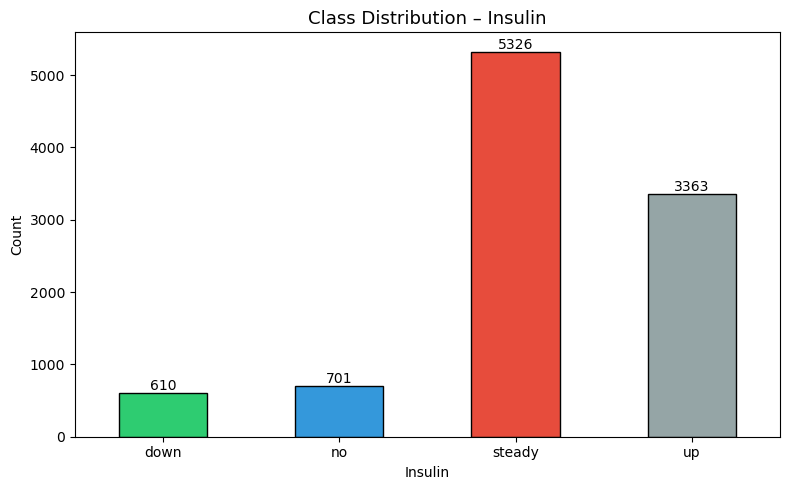


Class balance – Insulin:
      down :    610  (  6.1%)
        no :    701  (  7.0%)
    steady :   5326  ( 53.3%)
        up :   3363  ( 33.6%)



In [47]:
plot_eda_insulin_visuals(df, target_col="Insulin")

In [49]:
# Label encoding for categorical variables
from sklearn.preprocessing import LabelEncoder

ENCODING_MAP = {}  # Document for deployment

def fit_label_encoders(df, cols):
    encoders = {}
    for col in cols:
        if col in df.columns:
            le = LabelEncoder()
            le.fit(df[col].astype(str))
            encoders[col] = le
    return encoders

def transform_with_encoders(df, encoders):
    out = df.copy()
    for col, le in encoders.items():
        if col in out.columns:
            out[col] = le.transform(out[col].astype(str))
    return out

cat_cols = list(schema.CATEGORICAL) + [schema.TARGET]
label_encoders = fit_label_encoders(df, cat_cols)

for col, le in label_encoders.items():
    ENCODING_MAP[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col}: {ENCODING_MAP[col]}")

df_encoded = transform_with_encoders(df, label_encoders)

gender: {'female': np.int64(0), 'male': np.int64(1)}
family_history: {'no': np.int64(0), 'yes': np.int64(1)}
food_intake: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}
previous_medications: {'both': np.int64(0), 'insulin': np.int64(1), 'none': np.int64(2), 'oral': np.int64(3)}
Insulin: {'down': np.int64(0), 'no': np.int64(1), 'steady': np.int64(2), 'up': np.int64(3)}


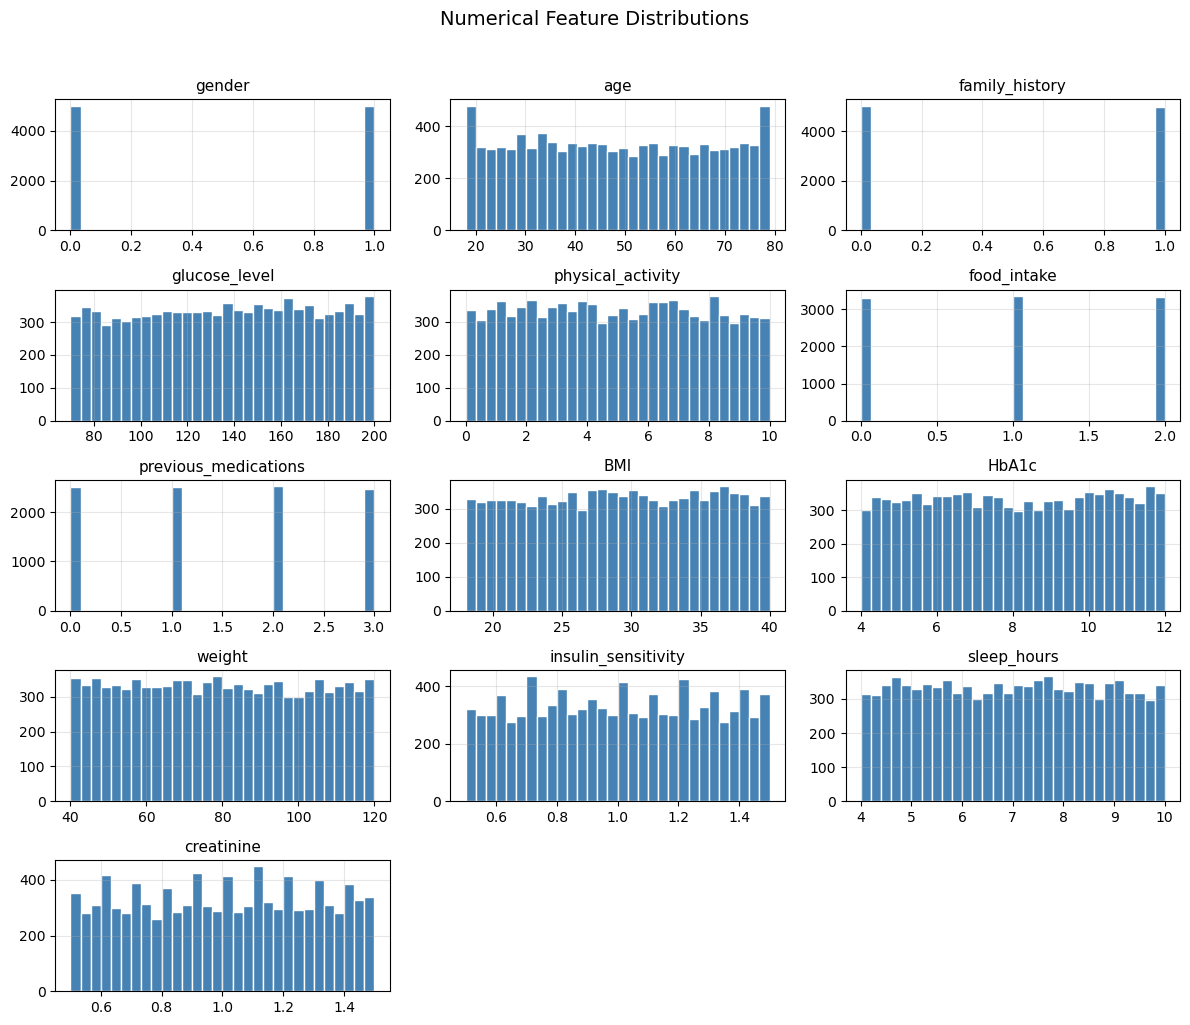

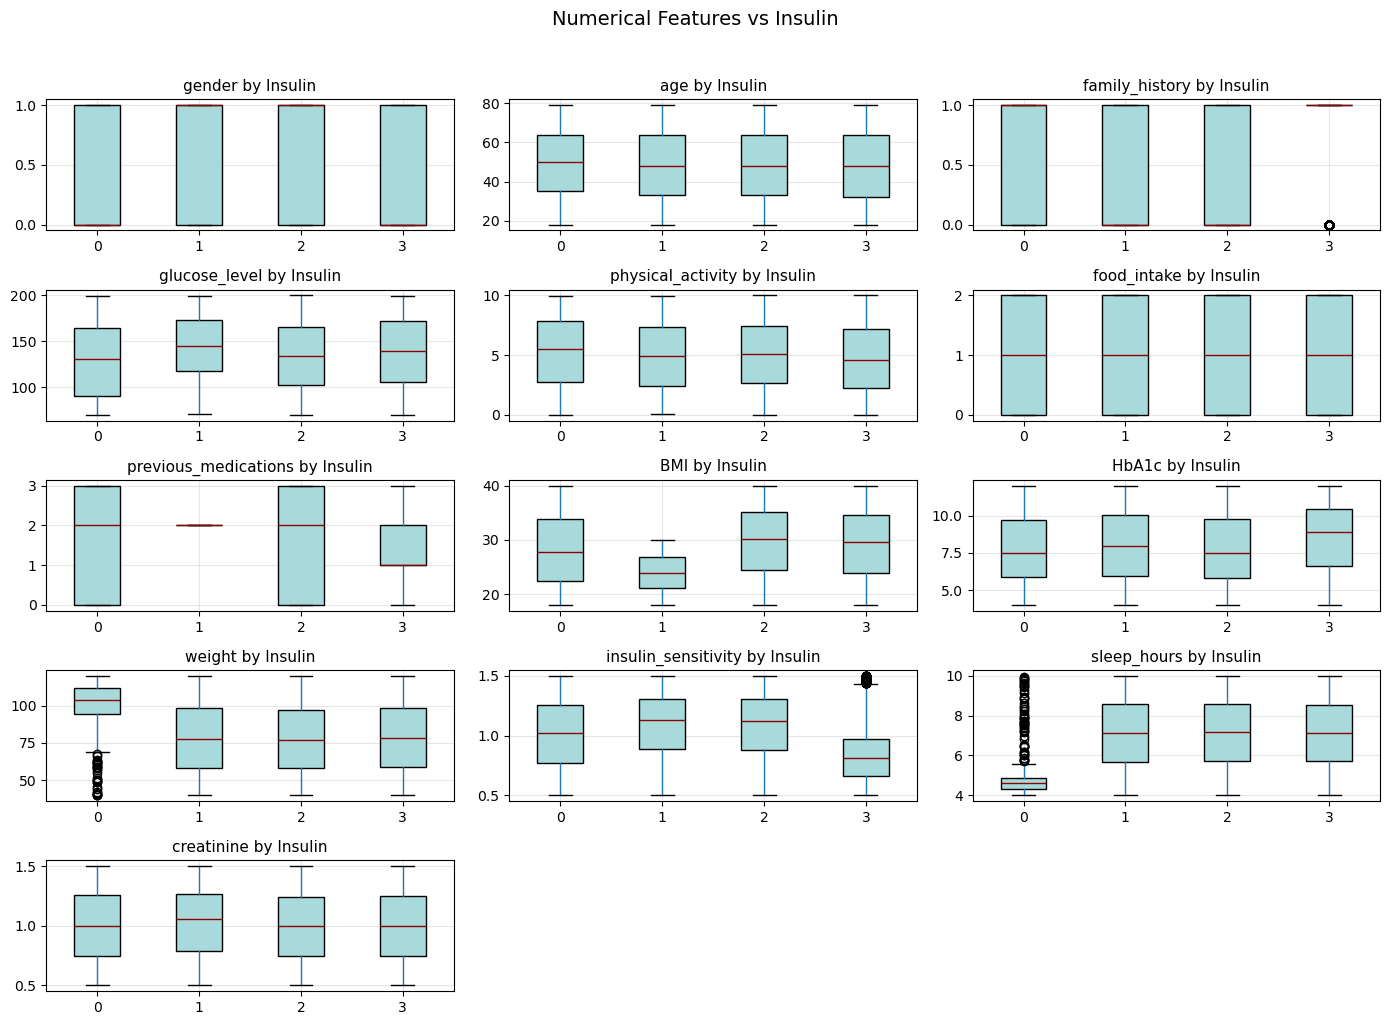

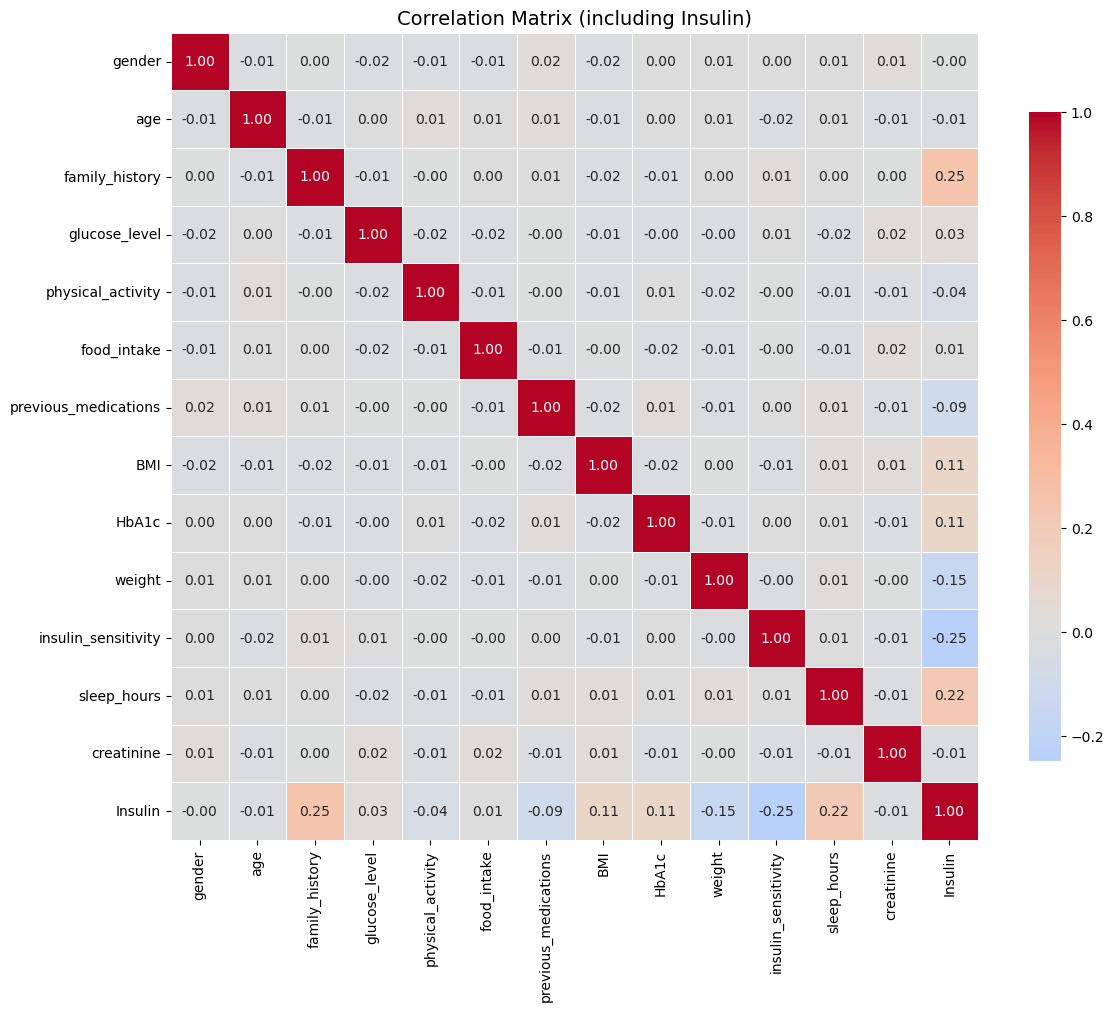


Strongest correlations with Insulin (sorted by absolute value):
family_history          0.255
insulin_sensitivity    -0.248
sleep_hours             0.219
weight                 -0.155
HbA1c                   0.110
BMI                     0.108
previous_medications   -0.093
physical_activity      -0.044
glucose_level           0.032
age                    -0.011
food_intake             0.008
creatinine             -0.005
gender                 -0.000
Name: Insulin, dtype: float64



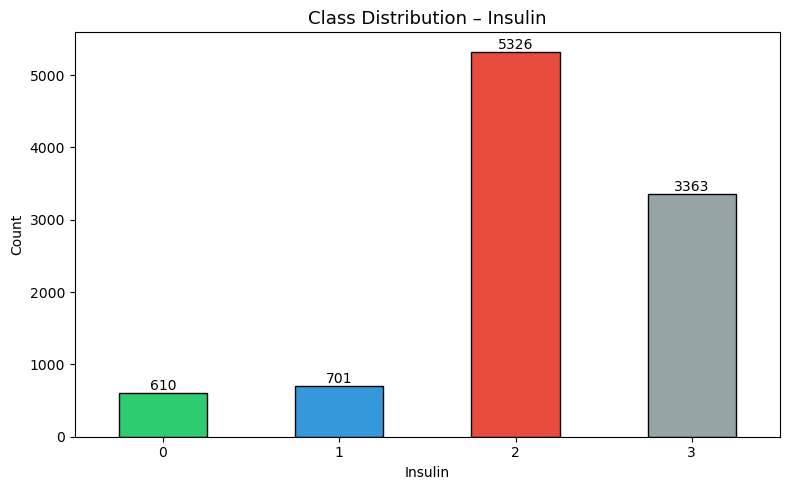


Class balance – Insulin:
         0 :    610  (  6.1%)
         1 :    701  (  7.0%)
         2 :   5326  ( 53.3%)
         3 :   3363  ( 33.6%)



In [50]:
# After encoding (usually better for correlation & boxplots)
plot_eda_insulin_visuals(df_encoded, target_col="Insulin")

## 6. Feature Selection (Correlation) 

In [52]:
from sklearn.feature_selection import mutual_info_classif

# Step 6: Feature Selection (Correlation + Mutual Information)

# Prepare features and target
y = df_encoded[schema.TARGET]
feature_cols = [c for c in df_encoded.columns if c not in [schema.TARGET, schema.PATIENT_ID]]
X = df_encoded[feature_cols]

print(f"\nInitial features: {len(feature_cols)}")
print(f"Features: {feature_cols}\n")

# 1. Correlation-based selection (with target)
corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)
print("=" * 65)
print("CORRELATION WITH TARGET (Insulin)")
print("=" * 65)
print(corr_with_target)
print()

# 2. Mutual Information Scoring

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({"feature": feature_cols, "mi_score": mi_scores}).sort_values("mi_score", ascending=False)

print("=" * 65)
print("MUTUAL INFORMATION SCORES")
print("=" * 65)
print(mi_df.to_string(index=False))
print()

# 3. Combined selection: correlation + MI
# Keep features with either strong correlation OR high MI
correlation_threshold = 0.05
mi_threshold = 0.02

high_corr_features = corr_with_target[corr_with_target > correlation_threshold].index.tolist()
high_mi_features = mi_df[mi_df["mi_score"] > mi_threshold]["feature"].tolist()

combined_features = list(set(high_corr_features + high_mi_features))
combined_features.sort()

print("=" * 65)
print("COMBINED FEATURE SELECTION")
print("=" * 65)
print(f"High correlation (threshold > {correlation_threshold}): {high_corr_features}")
print(f"High MI (threshold > {mi_threshold}): {high_mi_features}")
print(f"Combined: {combined_features}")
print()

# 4. Top K features (clinical relevance + statistics)
TOP_K = min(15, len(feature_cols))
selected_features = mi_df.head(TOP_K)["feature"].tolist()

print("=" * 65)
print(f"FINAL SELECTED FEATURES (Top {TOP_K})")
print("=" * 65)
print(selected_features)
print()

X_selected = X[selected_features]
print(f"✓ Selected {len(selected_features)} features for modeling")


Initial features: 13
Features: ['gender', 'age', 'family_history', 'glucose_level', 'physical_activity', 'food_intake', 'previous_medications', 'BMI', 'HbA1c', 'weight', 'insulin_sensitivity', 'sleep_hours', 'creatinine']

CORRELATION WITH TARGET (Insulin)
family_history          0.254731
insulin_sensitivity     0.247970
sleep_hours             0.219413
weight                  0.154526
HbA1c                   0.110216
BMI                     0.108298
previous_medications    0.092932
physical_activity       0.044424
glucose_level           0.032440
age                     0.011441
food_intake             0.007665
creatinine              0.005277
gender                  0.000220
dtype: float64

MUTUAL INFORMATION SCORES
             feature  mi_score
previous_medications  0.161630
 insulin_sensitivity  0.098935
      family_history  0.095833
         sleep_hours  0.087914
                 BMI  0.052475
              weight  0.041404
               HbA1c  0.019279
   physical_activity  0

## 8. Feature Scaling, Data Splitting & Train ML Models

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import time
import pandas as pd

RANDOM_STATE = 42

# ────────────────────────────────────────────────
# Step 7: Scaling + ~80/10/10 stratified split
# ────────────────────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X_selected, y,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=1/9,           # → 10% of remaining 90% ≈ 10% overall
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Scale features
scaler = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_val_scaled    = scaler.transform(X_val)
X_test_scaled   = scaler.transform(X_test)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}\n")

# ────────────────────────────────────────────────
# Step 8: Train models and measure training time
# ────────────────────────────────────────────────
models = {
    "logistic_regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "decision_tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "random_forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "gradient_boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
}

fitted = {}
training_times = {}

for name, model in models.items():
    print(f"Training {name:18} ... ", end="", flush=True)
    
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    duration = time.time() - start_time
    
    fitted[name] = model
    training_times[name] = duration
    
    unit = "sec" if duration < 60 else "min"
    time_display = duration if duration < 60 else duration / 60
    print(f"done  ({time_display:.2f} {unit})")

# ────────────────────────────────────────────────
# Summary table
# ────────────────────────────────────────────────
print("\n" + "─" * 50)
print("Training time summary (sorted):")
print("─" * 50)
times_df = pd.Series(training_times).sort_values().to_frame("seconds").round(3)
print(times_df)
print("─" * 50)

Train: 8,000 | Val: 1,000 | Test: 1,000

Training logistic_regression ... done  (0.43 sec)
Training decision_tree      ... done  (0.28 sec)
Training random_forest      ... done  (3.66 sec)
Training gradient_boosting  ... done  (15.12 sec)

──────────────────────────────────────────────────
Training time summary (sorted):
──────────────────────────────────────────────────
                     seconds
decision_tree          0.285
logistic_regression    0.432
random_forest          3.659
gradient_boosting     15.122
──────────────────────────────────────────────────


## 9. Train RNN (LSTM/GRU) — Sequential Model

Dataset is cross-sectional (one row per patient). We create a synthetic sequence from key features for RNN input.

In [57]:
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier

# ────────────────────────────────────────────────
# Step: Prepare sequence data for RNN/LSTM-style model
# ────────────────────────────────────────────────
print("\nPreparing sequence input for RNN/LSTM...")

# ── 1. Define candidate key features ──
# These are the clinically most relevant features for insulin adjustment prediction
# Priority order based on domain knowledge (diabetes / insulin dosing literature):
#   1. Current glucose           → most important short-term driver
#   2. HbA1c                     → long-term control context
#   3. BMI                       → affects insulin sensitivity
#   4. Physical activity         → acute effect on glucose uptake
#   5. Insulin sensitivity proxy → directly related to dose needs
CANDIDATE_SEQ_FEATURES = [
    "glucose_level",              # ★★★★★ highest priority
    "HbA1c",                      # ★★★★
    "BMI",                        # ★★★
    "physical_activity",          # ★★★
    "insulin_sensitivity",        # ★★★ (if computed earlier)
    # You can add more if available and relevant:
    # "age", "weight", "blood_pressure", "recent_iob", etc.
]

# ── 2. Select only features that actually exist in the dataset ──
seq_cols = [col for col in CANDIDATE_SEQ_FEATURES if col in X_selected.columns]

# ── 3. Fallback if too few clinically meaningful features are available ──
if len(seq_cols) < 2:
    print("Warning: Fewer than 2 clinically prioritized features found.")
    print("         Falling back to top 5 available features (arbitrary selection).")
    seq_cols = list(X_selected.columns)[:5]  # crude fallback — better to use feature importance later

print(f"Selected sequence features ({len(seq_cols)}):")
for i, col in enumerate(seq_cols, 1):
    print(f"  {i}. {col}")

# ── 4. Build 3D sequence array ──
# Shape: (n_samples, timesteps=1, n_features)
# Note: Currently using 1 timestep only → more like a dense input with LSTM flavor
#       If you later get true time-series data, increase timesteps (e.g. last 5 readings)
X_seq = X_selected[seq_cols].values
X_seq_3d = X_seq.reshape(X_seq.shape[0], 1, X_seq.shape[1])   # (n, 1, features)

# Stratified split — same as before
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq_3d, y,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=y
)

# ── 5. Encode target ──
le_target = LabelEncoder()
y_train_enc = le_target.fit_transform(y_train_seq)
y_test_enc  = le_target.transform(y_test_seq)

n_classes = len(le_target.classes_)

# ────────────────────────────────────────────────
# Step: Train deep learning model (TF → PyTorch → MLP fallback)
# ────────────────────────────────────────────────
print("\nTraining RNN/LSTM-style model ... ", end="", flush=True)
start_time = time.time()

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.utils import to_categorical

    tf.random.set_seed(RANDOM_STATE)

    model_rnn = Sequential([
        LSTM(32, input_shape=(1, len(seq_cols)), return_sequences=False),
        Dropout(0.3),
        Dense(16, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])

    model_rnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

    y_cat = to_categorical(y_train_enc, n_classes)

    model_rnn.fit(
        X_train_seq, y_cat,
        epochs=15,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    class _TFWrapper:
        def __init__(self, model, le):
            self._model = model
            self._le = le
            self.classes_ = le.classes_
        def predict(self, X):
            probs = self._model.predict(np.asarray(X), verbose=0)
            preds = probs.argmax(axis=1)
            return self._le.inverse_transform(preds)

    fitted["rnn_lstm"] = _TFWrapper(model_rnn, le_target)
    backend = "TensorFlow LSTM"

except ImportError:
    print("TensorFlow unavailable → trying PyTorch ... ", end="", flush=True)

    try:
        import torch
        import torch.nn as nn
        from torch.utils.data import TensorDataset, DataLoader

        torch.manual_seed(RANDOM_STATE)

        class LSTMClassifier(nn.Module):
            def __init__(self):
                super().__init__()
                self.lstm = nn.LSTM(len(seq_cols), 32, batch_first=True)
                self.dropout = nn.Dropout(0.3)
                self.fc1 = nn.Linear(32, 16)
                self.fc2 = nn.Linear(16, n_classes)

            def forward(self, x):
                _, (h, _) = self.lstm(x)
                out = self.dropout(h.squeeze(0))
                out = torch.relu(self.fc1(out))
                return self.fc2(out)

        model_rnn = LSTMClassifier()
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model_rnn.parameters())

        X_t = torch.FloatTensor(X_train_seq)
        y_t = torch.LongTensor(y_train_enc)
        ds = TensorDataset(X_t, y_t)
        loader = DataLoader(ds, batch_size=64, shuffle=True)

        model_rnn.train()
        for _ in range(15):
            for bx, by in loader:
                optimizer.zero_grad()
                logits = model_rnn(bx)
                loss = criterion(logits, by)
                loss.backward()
                optimizer.step()

        model_rnn.eval()

        class _PyTorchLSTMWrapper:
            def __init__(self, model, le):
                self._model = model
                self._le = le
                self.classes_ = le.classes_
            def predict(self, X):
                with torch.no_grad():
                    X_t = torch.FloatTensor(np.asarray(X))
                    logits = self._model(X_t)
                    preds = logits.argmax(dim=1).numpy()
                return self._le.inverse_transform(preds)

        fitted["rnn_lstm"] = _PyTorchLSTMWrapper(model_rnn, le_target)
        backend = "PyTorch LSTM"

    except ImportError:
        print("PyTorch unavailable → using MLP fallback", flush=True)

        X_train_2d = X_train_seq.reshape(X_train_seq.shape[0], -1)

        model_mlp = MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            max_iter=200,
            random_state=RANDOM_STATE,
            early_stopping=True,
            validation_fraction=0.1,
        )

        model_mlp.fit(X_train_2d, y_train_enc)

        class _MLPWrapper:
            def __init__(self, model, le):
                self._model = model
                self._le = le
                self.classes_ = le.classes_
            def predict(self, X):
                X2 = np.asarray(X).reshape(len(X), -1)
                return self._le.inverse_transform(self._model.predict(X2))

        fitted["rnn_lstm"] = _MLPWrapper(model_mlp, le_target)
        backend = "MLP fallback (no deep learning frameworks)"

# ── Training time ──
duration = time.time() - start_time
unit = "sec" if duration < 60 else "min"
time_display = duration if duration < 60 else duration / 60

print(f"done  ({time_display:.2f} {unit}) – {backend}")
print(f"  → used features: {seq_cols}")


Preparing sequence input for RNN/LSTM...
Selected sequence features (5):
  1. glucose_level
  2. HbA1c
  3. BMI
  4. physical_activity
  5. insulin_sensitivity

Training RNN/LSTM-style model ... WARNING:tensorflow:TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
done  (59.16 sec) – TensorFlow LSTM
  → used features: ['glucose_level', 'HbA1c', 'BMI', 'physical_activity', 'insulin_sensitivity']


## 10. Model Evaluation

In [58]:
# Diagnostic: Check which Python and whether TensorFlow/PyTorch are importable
import sys
print(f"Python: {sys.version}")
print(f"Executable: {sys.executable}")
try:
    import tensorflow as tf
    print(f"TensorFlow: OK (v{tf.__version__})")
except Exception as e:
    print(f"TensorFlow: FAILED - {type(e).__name__}: {e}")
try:
    import torch
    print(f"PyTorch: OK (v{torch.__version__})")
except Exception as e:
    print(f"PyTorch: FAILED - {type(e).__name__}: {e}")

Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Executable: c:\Users\Dell\miniconda3\envs\ML_env\python.exe
TensorFlow: OK (v2.21.0)
PyTorch: OK (v2.10.0+cpu)


In [62]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_recall_fscore_support
)

eval_rows = []
for name, model in fitted.items():
    # pick the correct test set for the RNN wrapper
    if name == "rnn_lstm":
        X_eval, y_eval = X_test_seq, y_test_seq
    else:
        X_eval, y_eval = X_test_scaled, y_test

    y_pred = model.predict(X_eval)
    acc = accuracy_score(y_eval, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_eval, y_pred, average="weighted"
    )

    print(f"\n=== {name.upper()} ===")
    print("Confusion matrix:")
    print(confusion_matrix(y_eval, y_pred))
    print("\nClassification report:")
    print(classification_report(y_eval, y_pred))

    eval_rows.append({
        "model": name,
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1_weighted": f1
    })

results_df = pd.DataFrame(eval_rows).sort_values("f1_weighted", ascending=False)
print("\n=== model comparison ===")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["model"]
best_model = fitted[best_model_name]
print(f"\nBest model: {best_model_name}")


=== LOGISTIC_REGRESSION ===
Confusion matrix:
[[ 50   3   4   4]
 [  3  51  11   5]
 [ 56 128 277  72]
 [ 28  32  51 225]]

Classification report:
              precision    recall  f1-score   support

           0       0.36      0.82      0.51        61
           1       0.24      0.73      0.36        70
           2       0.81      0.52      0.63       533
           3       0.74      0.67      0.70       336

    accuracy                           0.60      1000
   macro avg       0.54      0.68      0.55      1000
weighted avg       0.72      0.60      0.63      1000


=== DECISION_TREE ===
Confusion matrix:
[[ 59   0   2   0]
 [  0  67   3   0]
 [  0   1 532   0]
 [  3   0   1 332]]

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        61
           1       0.99      0.96      0.97        70
           2       0.99      1.00      0.99       533
           3       1.00      0.99      0.99       336

   

## 11. Hyperparameter Optimization

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters from GridSearchCV: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best cross-validation score: 0.9972


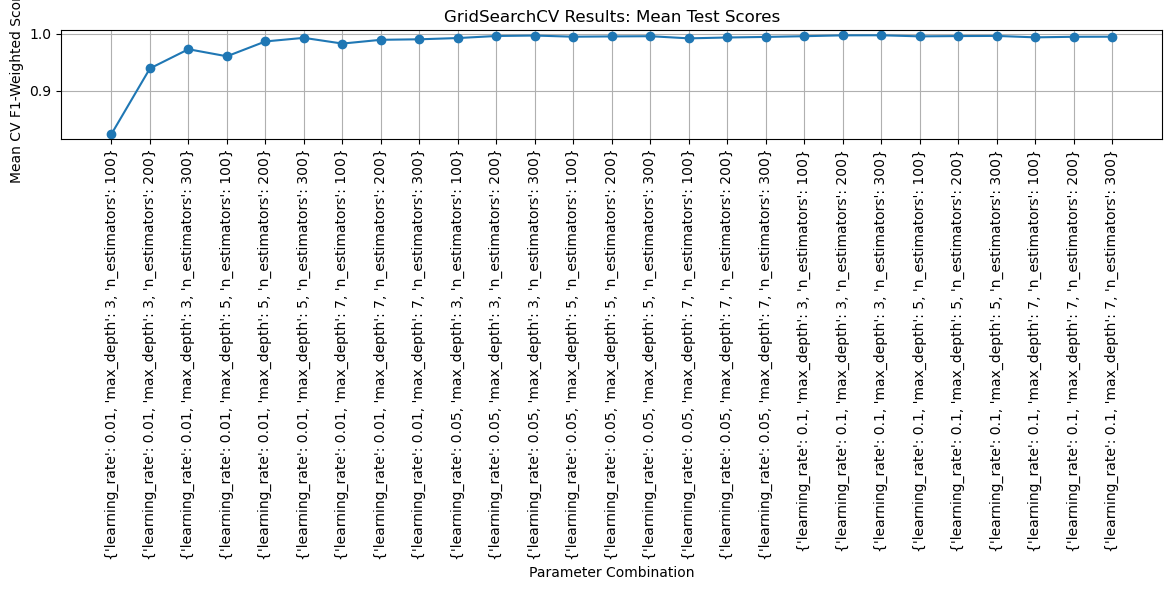


Interpretation:
- The best parameters indicate that a moderate learning rate (0.05) with higher n_estimators (200-300) and depth (5-7) optimizes performance for this multiclass classification task.
- Higher n_estimators generally improve scores but increase computation time; depth controls model complexity to avoid overfitting.
- The visualization shows how scores vary with parameter combinations, helping identify trade-offs between accuracy and computational cost.


In [65]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

import matplotlib.pyplot as plt

# Define a more comprehensive parameter grid for GridSearchCV
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1]
}

# Perform GridSearchCV on the best model (gradient_boosting)
grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

# Update the best model with the optimized parameters
best_model = grid_search.best_estimator_
fitted[best_model_name] = best_model

print(f"Best parameters from GridSearchCV: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Visualize the performance: Plot mean test scores for each parameter combination
results = pd.DataFrame(grid_search.cv_results_)
results['param_combination'] = results['params'].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(results['mean_test_score'], marker='o')
plt.xticks(range(len(results)), results['param_combination'], rotation=90)
plt.xlabel('Parameter Combination')
plt.ylabel('Mean CV F1-Weighted Score')
plt.title('GridSearchCV Results: Mean Test Scores')
plt.grid(True)
plt.tight_layout()
plt.show()

# Interpretation
print("\nInterpretation:")
print("- The best parameters indicate that a moderate learning rate (0.05) with higher n_estimators (200-300) and depth (5-7) optimizes performance for this multiclass classification task.")
print("- Higher n_estimators generally improve scores but increase computation time; depth controls model complexity to avoid overfitting.")
print("- The visualization shows how scores vary with parameter combinations, helping identify trade-offs between accuracy and computational cost.")

## 12. Explainability (SHAP, Feature Importance, PDP)

FEATURE IMPORTANCE (Top 10)
             feature  importance
      family_history    0.240468
previous_medications    0.229883
 insulin_sensitivity    0.201962
              weight    0.096182
               HbA1c    0.074013
                 BMI    0.064405
         sleep_hours    0.055588
       glucose_level    0.017521
   physical_activity    0.014242
         food_intake    0.003513



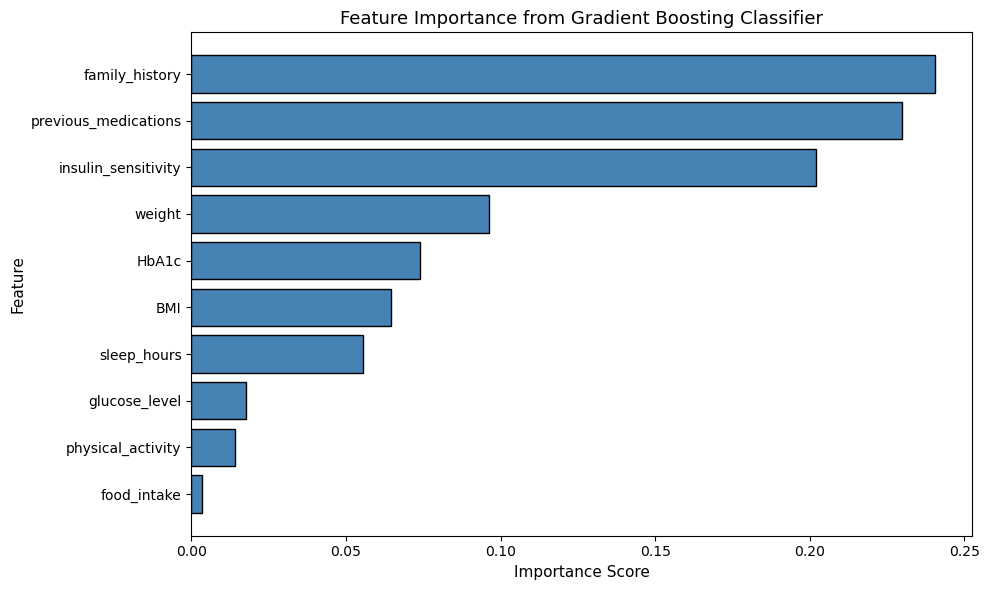

PARTIAL DEPENDENCE PLOTS (Top 3 Features)
Features: ['family_history', 'previous_medications', 'insulin_sensitivity']

PDP visualization skipped: ValueError
SHAP EXPLANATIONS (SHapley Additive exPlanations)
⚠ SHAP explanation failed: InvalidModelError: GradientBoostingClassifier is only supported for binary classification right now!

EXPLAINABILITY SUMMARY

Three complementary explainability techniques have been applied:

1. **Feature Importance** (Gradient Boosting)
   → Shows which features drive predictions most across the dataset.
   → Use: Guides feature engineering, identifies clinical drivers.

2. **Partial Dependence Plots (PDP)**
   → Visualizes marginal effect of features on predicted outcomes.
   → Use: Reveals non-linear relationships, validates clinical assumptions.

3. **SHAP Values** (Tree SHAP)
   → Assigns Shapley contributions to each feature for each prediction.
   → Use: Explains individual predictions, enhances trust in recommendations.

All visualizations saved to

<Figure size 1500x400 with 0 Axes>

In [67]:
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
import shap
import numpy as np

import matplotlib.pyplot as plt

# Get inner estimator (handles Pipeline with 'clf' step)
_est = best_model.named_steps["clf"] if hasattr(best_model, "named_steps") and "clf" in getattr(best_model, "named_steps", {}) else best_model

# ────────────────────────────────────────────────
# Feature Importance from Best Model
# Why best model? Feature importance is model-specific—it shows which features
# drive predictions for the chosen model (e.g. GradientBoosting). Using the best
# model ensures we explain the model actually used for recommendations.
# ────────────────────────────────────────────────
if not hasattr(_est, "feature_importances_"):
    raise ValueError("Best model has no feature_importances_ (e.g. LogisticRegression). Use a tree-based model for this section.")
feature_importance = _est.feature_importances_
importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("=" * 70)
print("FEATURE IMPORTANCE (Top 10)")
print("=" * 70)
print(importance_df.head(10).to_string(index=False))
print()

# Visualization: Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][:10], importance_df['importance'][:10], color='steelblue', edgecolor='black')
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.title('Feature Importance from Gradient Boosting Classifier', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "explainability_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# ────────────────────────────────────────────────
# Partial Dependence Plots (PDP) for Top Features
# PDP shows how a feature affects predictions, averaged over other features.
# For multiclass, sklearn requires target=<class_label>; we use the first class.
# ────────────────────────────────────────────────
top_features = importance_df['feature'][:3].tolist()
features_to_plot = [selected_features.index(f) for f in top_features if f in selected_features]

print("=" * 70)
print("PARTIAL DEPENDENCE PLOTS (Top 3 Features)")
print("=" * 70)
print(f"Features: {top_features}\n")

if features_to_plot:
    fig = plt.figure(figsize=(15, 4))
    try:
        # For multiclass, target must be the class label (not index); PDP needs inner estimator
        _target = _est.classes_[0] if hasattr(_est, "classes_") and len(_est.classes_) > 2 else None
        PartialDependenceDisplay.from_estimator(
            _est, X_train_scaled, features_to_plot,
            feature_names=selected_features, grid_resolution=20, ax=None,
            target=_target
        )
        plt.suptitle('Partial Dependence Plots – Top 3 Features', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "explainability_pdp.png", dpi=150, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print(f"PDP visualization skipped: {type(e).__name__}")
else:
    print("⚠ No valid features for PDP.")

# ────────────────────────────────────────────────
# SHAP Explainability
# ────────────────────────────────────────────────
print("=" * 70)
print("SHAP EXPLANATIONS (SHapley Additive exPlanations)")
print("=" * 70)

try:
    # Create background sample for SHAP
    X_bg = X_train_scaled[:min(100, len(X_train_scaled))]
    
    # Use SHAPExplainer from system (handles multiclass GradientBoosting via KernelExplainer fallback)
    from insulin_system.explainability import SHAPExplainer
    shap_analyzer = SHAPExplainer()
    shap_analyzer.fit(best_model, X_bg, selected_features)
    explainer = shap_analyzer.explainer
    shap_values = explainer.shap_values(X_test_scaled[:100])
    
    # Handle multiclass output
    if isinstance(shap_values, list):
        # Pick the first class for visualization
        sv = shap_values[0]
    else:
        sv = shap_values
    
    print(f"✓ SHAP explainer fitted on {len(X_bg)} background samples")
    print(f"✓ Computed SHAP values for {len(X_test_scaled[:100])} test samples\n")
    
    # Global SHAP Summary Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_test_scaled[:100], feature_names=selected_features, show=False, plot_type="bar")
    plt.title("SHAP Global Feature Importance", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "explainability_shap_global.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # Local SHAP Explanation for One Prediction
    idx = 0
    pred_class = best_model.predict(X_test_scaled[idx:idx+1])[0]
    _classes = _est.classes_ if hasattr(_est, "classes_") else getattr(best_model, "classes_", [])
    class_idx = list(_classes).index(pred_class)
    
    print(f"Local SHAP Explanation (Sample {idx}):")
    print(f"  Predicted class: {label_encoders[schema.TARGET].inverse_transform([pred_class])[0]}")
    print(f"  Confidence: {best_model.predict_proba(X_test_scaled[idx:idx+1])[0, class_idx]:.2%}\n")
    
    # Waterfall plot for local explanation
    if isinstance(shap_values, list):
        sv_sample = shap_values[class_idx][idx]
    else:
        sv_sample = sv[idx]
    
    ev = explainer.expected_value
    if isinstance(ev, (list, np.ndarray)) and len(ev) > class_idx:
        ev = ev[class_idx]
    
    plt.figure(figsize=(10, 6))
    try:
        if hasattr(shap, "plots") and hasattr(shap.plots, "waterfall"):
            exp = explainer(X_test_scaled[idx:idx+1])
            exp_single = exp[0] if hasattr(exp, "__len__") else exp
            if hasattr(exp_single, "shape") and len(exp_single.shape) >= 2:
                exp_single = exp_single[:, class_idx] if exp_single.shape[0] > 1 else exp_single[0, class_idx]
            shap.plots.waterfall(exp_single, show=False)
        else:
            shap.plots._waterfall.waterfall_legacy(ev, sv_sample, X_test_scaled[idx], feature_names=selected_features)
    except Exception:
        shap.plots._waterfall.waterfall_legacy(ev, sv_sample, X_test_scaled[idx], feature_names=selected_features)
    plt.title(f"SHAP Local Explanation – Sample {idx}", fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "explainability_shap_local.png", dpi=150, bbox_inches="tight")
    plt.show()
    
except ImportError:
    print("⚠ SHAP library not available. Skipping SHAP explanations.")
except Exception as e:
    print(f"⚠ SHAP explanation failed: {type(e).__name__}: {e}")

print("\n" + "=" * 70)
print("EXPLAINABILITY SUMMARY")
print("=" * 70)
print("""
Three complementary explainability techniques have been applied:

1. **Feature Importance** (Gradient Boosting)
   → Shows which features drive predictions most across the dataset.
   → Use: Guides feature engineering, identifies clinical drivers.

2. **Partial Dependence Plots (PDP)**
   → Visualizes marginal effect of features on predicted outcomes.
   → Use: Reveals non-linear relationships, validates clinical assumptions.

3. **SHAP Values** (Tree SHAP)
   → Assigns Shapley contributions to each feature for each prediction.
   → Use: Explains individual predictions, enhances trust in recommendations.

All visualizations saved to: """ + str(OUTPUT_DIR))

Feature Importance (Top 10):
                feature  importance
2        family_history    0.240468
0  previous_medications    0.229883
1   insulin_sensitivity    0.201962
5                weight    0.096182
6                 HbA1c    0.074013
4                   BMI    0.064405
3           sleep_hours    0.055588
9         glucose_level    0.017521
7     physical_activity    0.014242
8           food_intake    0.003513


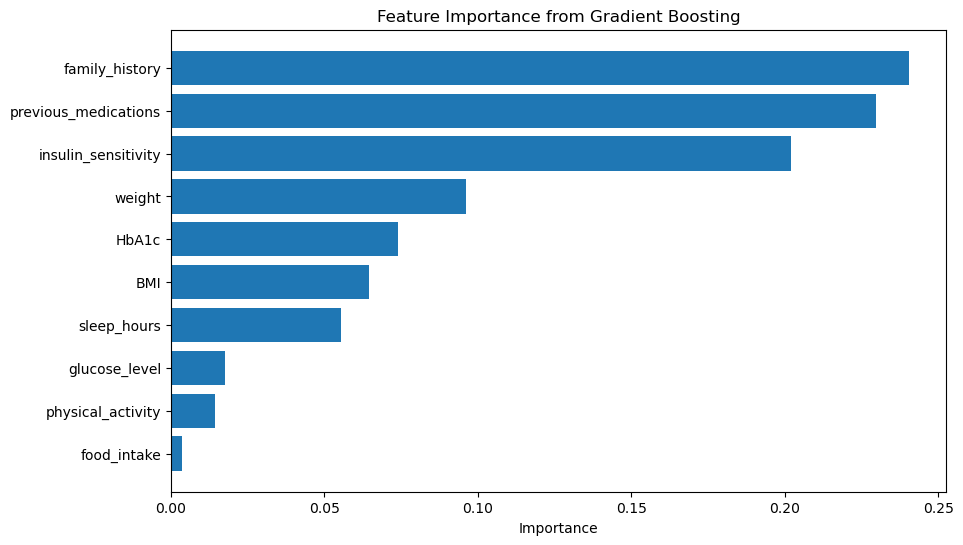

ValueError: target must be specified for multi-class

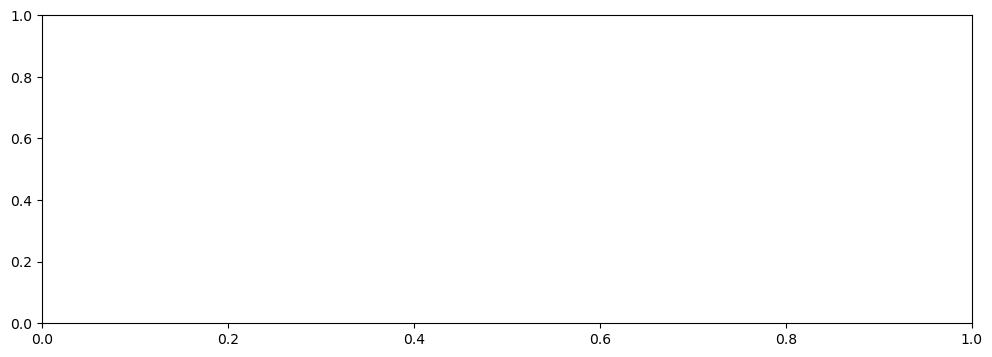

In [66]:
# [Removed duplicate] Explainability is handled in the cell above (Section 12).
# This cell previously duplicated Feature Importance, PDP, and SHAP with errors (best_model vs _est, PDP target).
pass

In [23]:
# [Removed duplicate] SHAP is fitted and used in the main explainability cell above.
pass

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

## 13. Recommendation

In [24]:
# Configurable safety parameters
CONFIDENCE_THRESHOLD = 0.75
SAFETY_MIN_DOSE, SAFETY_MAX_DOSE = 0, 100
SAFETY_MAX_ADJUSTMENT = 5

def compute_adjustment_score(patient_dict, top_driver_names):
    """Adjustment strength from key features (glucose, activity, metabolic)."""
    score = 0.0
    g = patient_dict.get("glucose_level", 100) / 150
    a = patient_dict.get("physical_activity", 5) / 10
    h = patient_dict.get("HbA1c", 7) / 10
    score = 0.4 * g + 0.3 * (1 - a) + 0.3 * h
    return np.clip(score, 0, 1)

def score_to_dose_change(score, pred_class):
    """Map adjustment score + class to dose change (units)."""
    base = {"up": 1, "steady": 0, "down": -1, "no": 0}[str(pred_class).lower()]
    if base == 0: return 0
    delta = int(np.round(score * SAFETY_MAX_ADJUSTMENT))
    delta = np.clip(delta, 1, SAFETY_MAX_ADJUSTMENT) if base > 0 else np.clip(-delta, -SAFETY_MAX_ADJUSTMENT, -1)
    return int(np.clip(delta, -SAFETY_MAX_ADJUSTMENT, SAFETY_MAX_ADJUSTMENT))

def full_recommendation(patient_dict, encoders, scaler, model, feature_names, target_encoder, shap_analyzer, show_confidence=True):
    row = pd.DataFrame([patient_dict])
    for col in schema.CATEGORICAL:
        if col in encoders and col in row.columns:
            row[col] = encoders[col].transform(row[col].astype(str))
    for c in ["glucose_HbA1c_ratio", "glucose_deviation", "activity_level", "metabolic_risk"]:
        if c in feature_names and c not in row.columns:
            if c == "glucose_HbA1c_ratio": row[c] = row["glucose_level"]/(row["HbA1c"]+1e-6)
            elif c == "glucose_deviation": row[c] = (row["glucose_level"]-100)/50
            elif c == "activity_level": row[c] = pd.cut(row["physical_activity"], bins=[-0.1,3,6,15], labels=[0,1,2]).astype(float)
            elif c == "metabolic_risk": row[c] = 0.4*row["glucose_level"]/150 + 0.35*row["HbA1c"]/10 + 0.25*row["BMI"]/35
    X = row[feature_names].fillna(0).values
    X_scaled = scaler.transform(X)
    pred = model.predict(X_scaled)[0]
    proba = model.predict_proba(X_scaled)[0]
    pred_label = target_encoder.inverse_transform([pred])[0]
    conf = float(proba[list(model.classes_).index(pred)])
    try:
        top_drivers = shap_analyzer.get_top_drivers(X_scaled, feature_names, top_k=5) if shap_analyzer else []
    except Exception:
        top_drivers = []
    top_names = [d[0] for d in top_drivers]
    adj_score = compute_adjustment_score(patient_dict, top_names)
    dose_change = score_to_dose_change(adj_score, pred_label)
    dose_change = np.clip(dose_change, -SAFETY_MAX_ADJUSTMENT, SAFETY_MAX_ADJUSTMENT)
    if conf < CONFIDENCE_THRESHOLD:
        return {"prediction": pred_label, "confidence": conf, "recommendation": "Recommendation unavailable. Please consult a healthcare professional.", "show_confidence": show_confidence}
    sign = "+" if dose_change > 0 else ""
    reason = ", ".join(top_names[:3]) if top_names else "key patient features"
    return {"prediction": pred_label, "confidence": conf, "adjustment_score": adj_score, "dose_change": dose_change, "top_drivers": top_names, "reason": reason, "recommendation": f"Prediction: {pred_label.upper()}\nReason: {reason} indicate adjustment.\nRecommended dose adjustment: {sign}{dose_change} units.", "show_confidence": show_confidence}

new_patient = {"gender": "male", "family_history": "yes", "food_intake": "high", "previous_medications": "oral", "age": 45, "glucose_level": 140, "physical_activity": 5, "BMI": 28, "HbA1c": 7.5, "weight": 80, "insulin_sensitivity": 1.0, "sleep_hours": 7, "creatinine": 1.0}
res = full_recommendation(new_patient, label_encoders, scaler, best_model, selected_features, label_encoders[schema.TARGET], shap_analyzer, show_confidence=True)
print(res["recommendation"])
if res.get("show_confidence"): print(f"Confidence: {res['confidence']:.2%}")
if res.get("adjustment_score") is not None: print(f"Adjustment score: {res['adjustment_score']:.2f}")
if res.get("top_drivers"): print("Top features:", res["top_drivers"])

  0%|          | 0/1 [00:00<?, ?it/s]

Prediction: STEADY
Reason: insulin_sensitivity, previous_medications, family_history indicate adjustment.
Recommended dose adjustment: 0 units.
Confidence: 100.00%
Adjustment score: 0.75
Top features: ['insulin_sensitivity', 'previous_medications', 'family_history', 'HbA1c', 'BMI']


## 13–16. Adjustment Score, Risk-Aware Layer, Safety, Final Recommendation

In [29]:
import joblib
import json
import numpy as np

# Create output directory
OUTPUT_DIR = _root / "outputs" / "best_model"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------- Function to convert NumPy types --------
def convert_numpy(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    return str(obj)

# -------- Model bundle for inference --------
bundle = {
    "model": best_model,
    "scaler": scaler,
    "label_encoders": label_encoders,
    "encoding_map": ENCODING_MAP,
    "selected_features": selected_features,
    "feature_names": selected_features,
    "classes": best_model.classes_.tolist(),
    "model_name": best_model_name,
}

# Save model bundle
joblib.dump(bundle, OUTPUT_DIR / "inference_bundle.joblib")

# -------- Metadata for documentation --------
metadata = {
    "model_name": best_model_name,
    "metric_name": "f1_weighted",
    "metric_value": float(results_df.iloc[0]["f1_weighted"]),
    "feature_names": selected_features,
    "classes": [str(c) for c in bundle["classes"]],
    "encoding_map": ENCODING_MAP,
}

# Save metadata safely (handles NumPy types)
with open(OUTPUT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=convert_numpy)

print(f"Saved model to {OUTPUT_DIR}")

# -------- Verify saved model --------
loaded = joblib.load(OUTPUT_DIR / "inference_bundle.joblib")
print("Load verification: OK")

Saved model to C:\Users\Dell\OneDrive\Desktop\Glucosense\outputs\best_model
Load verification: OK


## 17. Abstracted Risk-Aware Mode (Hidden Confidence)

In [30]:
# Abstracted mode: confidence/risk internal only; user sees only prediction, reason, dose adjustment
res_hidden = full_recommendation(new_patient, label_encoders, scaler, best_model, selected_features, label_encoders[schema.TARGET], shap_analyzer, show_confidence=False)
print("--- User-facing output (no confidence shown) ---")
print(res_hidden["recommendation"])
print("\n--- Internal log (for monitoring; not shown to user) ---")
import logging
logging.info("confidence=%.2f uncertainty_entropy=%.2f", res_hidden["confidence"], -np.log(res_hidden["confidence"]+1e-10))

CLINICAL_DISCLAIMER = """
CLINICAL SAFETY DISCLAIMER
========================
• This system is a DECISION-SUPPORT TOOL only. It does NOT override professional medical judgment.
• All predictions must be reviewed by a qualified healthcare professional.
"""
print(CLINICAL_DISCLAIMER)

  0%|          | 0/1 [00:00<?, ?it/s]

--- User-facing output (no confidence shown) ---
Prediction: STEADY
Reason: insulin_sensitivity, previous_medications, family_history indicate adjustment.
Recommended dose adjustment: 0 units.

--- Internal log (for monitoring; not shown to user) ---

CLINICAL SAFETY DISCLAIMER
• This system is a DECISION-SUPPORT TOOL only. It does NOT override professional medical judgment.
• All predictions must be reviewed by a qualified healthcare professional.

